### Download data

In [1]:
from datasets import load_dataset

ds = load_dataset("mychen76/invoices-and-receipts_ocr_v1")

data/train-00000-of-00001-76ffc8319f74dd(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

c:\Users\drive\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\drive\.cache\huggingface\hub\datasets--mychen76--invoices-and-receipts_ocr_v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/test-00000-of-00001-af2d92d1cee2851(…):   0%|          | 0.00/18.8M [00:00<?, ?B/s]

data/valid-00000-of-00001-894b4e1f736b57(…):   0%|          | 0.00/14.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/125 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/70 [00:00<?, ? examples/s]

In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 2043
    })
    test: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 125
    })
    valid: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 70
    })
})


In [ ]:
ds.save_to_disk("dataset/invoices-and-receipts_ocr_v1")

Saving the dataset (0/1 shards):   0%|          | 0/2043 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/125 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/70 [00:00<?, ? examples/s]

### Load data

In [1]:
from datasets import load_from_disk

dataset = load_from_disk("dataset/invoices-and-receipts_ocr_v1")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 2043
    })
    test: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 125
    })
    valid: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 70
    })
})


### Explore dataset

In [2]:
# Display basic information about each split
for split_name, split_data in dataset.items():
    print(f"\n{split_name.upper()} split:")
    print(f"  Number of rows: {split_data.num_rows}")
    print(f"  Features: {split_data.column_names}")
    print(f"  First example:\n{split_data[0]}")


TRAIN split:
  Number of rows: 2043
  Features: ['image', 'id', 'parsed_data', 'raw_data']
  First example:
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2481x3508 at 0x21C59519600>, 'id': '0', 'parsed_data': '{"xml": "", "json": "{\'header\': {\'invoice_no\': \'40378170\', \'invoice_date\': \'10/15/2012\', \'seller\': \'Patel, Thompson and Montgomery 356 Kyle Vista New James, MA 46228\', \'client\': \'Jackson, Odonnell and Jackson 267 John Track Suite 841 Jenniferville, PA 98601\', \'seller_tax_id\': \'958-74-3511\', \'client_tax_id\': \'998-87-7723\', \'iban\': \'GB77WRBQ31965128414006\'}, \'items\': [{\'item_desc\': \\"Leed\'s Wine Companion Bottle Corkscrew Opener Gift Box Set with Foil Cutter\\", \'item_qty\': \'1,00\', \'item_net_price\': \'7,50\', \'item_net_worth\': \'7,50\', \'item_vat\': \'10%\', \'item_gross_worth\': \'8,25\'}], \'summary\': {\'total_net_worth\': \'$7,50\', \'total_vat\': \'$0,75\', \'total_gross_worth\': \'$8,25\'}}", "kie": ""}', 'raw_d

In [7]:
# Display the arrow schema and file structure
print("Dataset schema:")
try:
    print(dataset['train'].features)
    print(dataset['train'].data.schema)
except AttributeError:
    print("Arrow schema not available; showing column names instead:")
    print(dataset['train'].column_names)

print("\nDataset info:")
dataset['train'].info

Dataset schema:
{'image': Image(mode=None, decode=True), 'id': Value('string'), 'parsed_data': Value('string'), 'raw_data': Value('string')}
image: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
id: string
parsed_data: string
raw_data: string
-- schema metadata --
huggingface: '{"info": {"features": {"image": {"_type": "Image"}, "id": {' + 144

Dataset info:


DatasetInfo(features={'image': Image(mode=None, decode=True), 'id': Value('string'), 'parsed_data': Value('string'), 'raw_data': Value('string')}, builder_name='parquet', dataset_name='invoices-and-receipts_ocr_v1', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=331975075, num_examples=2043, dataset_name='invoices-and-receipts_ocr_v1'), 'test': SplitInfo(name='test', num_bytes=23811234, num_examples=125, dataset_name='invoices-and-receipts_ocr_v1'), 'valid': SplitInfo(name='valid', num_bytes=22327172, num_examples=70, dataset_name='invoices-and-receipts_ocr_v1')}, download_size=281665599, dataset_size=378113481, size_in_bytes=659779080)

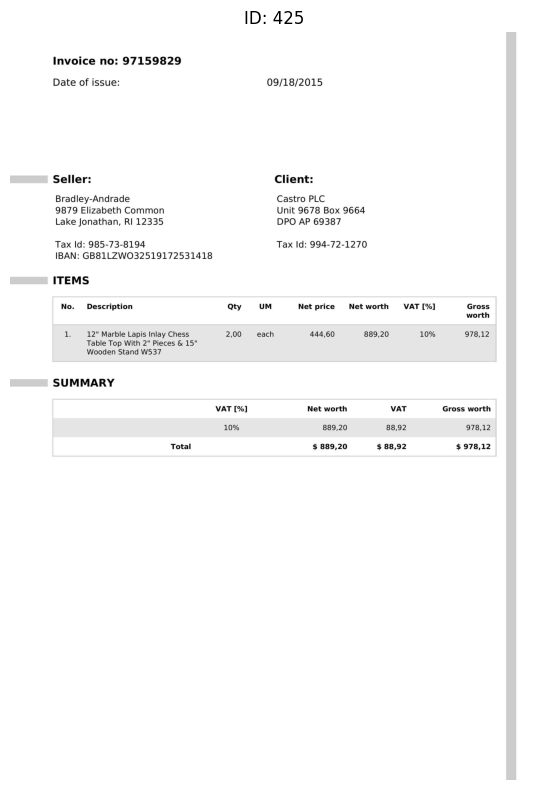

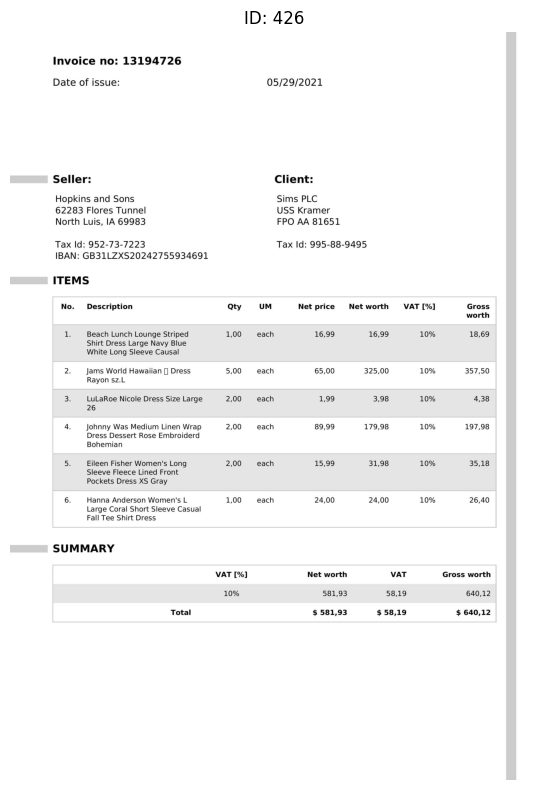

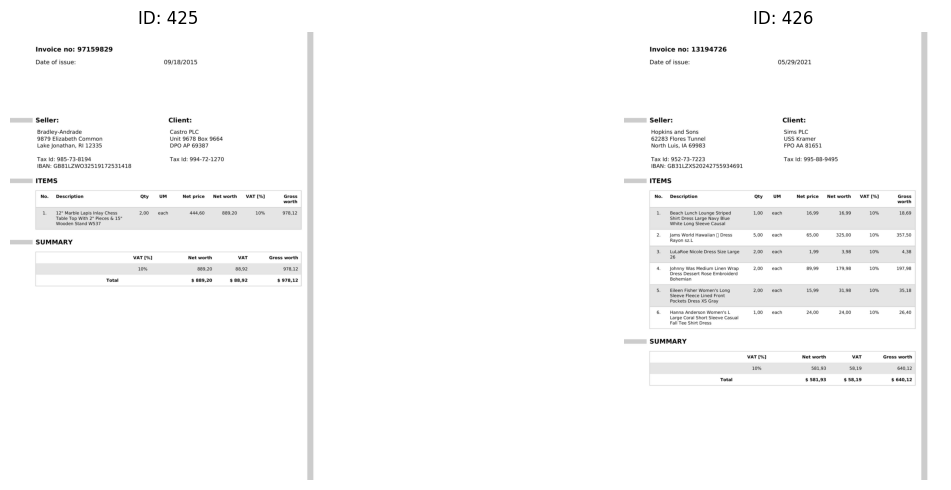

In [13]:
from PIL import Image

import matplotlib.pyplot as plt

# Explore some images in test split
test_split = dataset['test']
num_images_to_show = 2
for i in range(num_images_to_show):
    fig, ax = plt.subplots(figsize=(10, 8))
    image = test_split[i]['image']
    image_id = test_split[i]['id']
    
    ax.imshow(image)
    ax.set_title(f"ID: {image_id}")
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
fig, axes = plt.subplots(1, num_images_to_show, figsize=(15, 5))

for i in range(num_images_to_show):
    image = test_split[i]['image']
    image_id = test_split[i]['id']
    
    axes[i].imshow(image)
    axes[i].set_title(f"ID: {image_id}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()